# 05. 보조 접근성 데이터 EDA

이 노트북은 난이도 지수를 계산하기 전에, 보유한 보조 원천 데이터가 **중앙대학교 정문 반경 약 800m 보행망의 edge 단위 분석에 실제로 쓸 수 있는지** 확인하기 위한 탐색적 분석(EDA)입니다.

대상 데이터는 다음 네 가지입니다.

- 음향신호기 현황: 좌표가 투영좌표계(EPSG:5186)인 점 데이터
- 장애인편의시설 목록: 시설 위도·경도가 있는 건물/시설 데이터
- 지하철 시각장애인 음성유도기: 역명·설치위치 중심의 비공간 데이터
- 보행자 사고 다발지역: 위도·경도 및 폴리곤이 있는 위험 데이터

이 단계에서는 점수나 가중치를 정하지 않습니다. 각 데이터의 범위, 품질, 좌표, 결측치, 공간 매칭 가능성을 확인한 뒤 다음 단계의 edge 결합 규칙을 설계합니다.

In [163]:
from pathlib import Path
import json

import folium
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import pandas as pd
from IPython.display import display
from shapely.geometry import Point, shape

# Windows 한글 그래프 폰트 설정 (맑은 고딕)
rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / 'data').exists():
    # Jupyter를 상위 폴더에서 실행한 경우를 대비한 보정
    PROJECT_DIR = PROJECT_DIR / 'DartB_TOYPROJECT'

DATASETS = {
    'audible_signal': PROJECT_DIR / '음향신호기_현황.csv',
    'facility': PROJECT_DIR / '서울시_장애인편의시설_목록정보(한국사회보장정보원)_.csv',
    'subway_voice': PROJECT_DIR / '서울교통공사_지하철_시각장애인_음성유도기_설치_위치_정보_20260213.csv',
    'accident': PROJECT_DIR / '보행자_사고_다발지역.csv',
}

# 기존 수집/스냅 단계와 동일한 중심점 및 분석 반경
CENTER_LAT, CENTER_LON = 37.50457, 126.95696
RADIUS_M = 800

for name, path in DATASETS.items():
    print(f'{name}: {path.name} | exists={path.exists()}')

audible_signal: 음향신호기_현황.csv | exists=True
facility: 서울시_장애인편의시설_목록정보(한국사회보장정보원)_.csv | exists=True
subway_voice: 서울교통공사_지하철_시각장애인_음성유도기_설치_위치_정보_20260213.csv | exists=True
accident: 보행자_사고_다발지역.csv | exists=True


In [164]:
def read_csv_flexible(path, **kwargs):
    """UTF-8/CP949 계열 CSV를 순서대로 시도해 읽는다."""
    errors = []
    for encoding in ('utf-8-sig', 'utf-8', 'cp949', 'euc-kr'):
        try:
            frame = pd.read_csv(path, encoding=encoding, **kwargs)
            print(f'{path.name}: encoding={encoding}, rows={len(frame):,}, cols={len(frame.columns)}')
            return frame
        except UnicodeDecodeError as exc:
            errors.append(f'{encoding}: {exc}')
    raise UnicodeDecodeError('unknown', b'', 0, 1, '\n'.join(errors))

def profile(frame, name, preview_rows=3):
    """행·열 수, 자료형, 결측치, 중복 행과 표본을 빠르게 확인한다."""
    print(f'\n[{name}] shape={frame.shape}, duplicate rows={frame.duplicated().sum():,}')
    summary = pd.DataFrame({
        'dtype': frame.dtypes.astype(str),
        'missing_n': frame.isna().sum(),
        'missing_pct': (frame.isna().mean() * 100).round(2),
        'nunique': frame.nunique(dropna=True),
    }).sort_values(['missing_pct', 'nunique'], ascending=[False, False])
    display(summary)
    display(frame.head(preview_rows))
    return summary

## 원천 데이터별 관찰

각 데이터는 독립된 셀에서 불러오고 관찰합니다. 바로 다음 셀은 해당 데이터프레임의 컬럼명만 표시합니다.

In [165]:
# 1) 음향신호기 현황
audible = read_csv_flexible(DATASETS['audible_signal'])
audible_summary = profile(audible, '음향신호기')

음향신호기_현황.csv: encoding=utf-8-sig, rows=21,451, cols=22

[음향신호기] shape=(21451, 22), duplicate rows=0


,dtype,missing_n,missing_pct,nunique
MNG_AGEN,float64,21243,99.03,2
SL_NUM,str,18485,86.17,68
DRN_CDE,float64,9314,43.42,8
POS,float64,9314,43.42,1
geometry,str,4604,21.46,16847
YCE,float64,4604,21.46,16842
XCE,float64,4604,21.46,16841
MK_CPY,str,2496,11.64,143
CTK_MGRNU,str,1265,5.90,2157
CAE_YMD,float64,890,4.15,2485


,MGRNU,A062_MGRNU,DRN_CDE,ESB_YMD,CAE_YMD,XCE,YCE,MK_CPY,SL_NUM,WORK_CDE,...,SIXID,STAT_CDE,CTK_MGRNU,SD_MGRNU,HISID,POS,FRM_CDE,MNG_AGEN,XGEO,geometry
0,24-0000011058,02-0000180110,0.0,20151026.0,20230102.0,187968.300000,549055.306244,대한신호,NaN,6,...,1264566.0,1.0,2023-0101-005,24-011058,15786,1.0,2.0,NaN,oracle.sql.STRUCT@15216338,POINT (187968.299999927 549055.306243806)
1,24-0000011081,02-0000180117,0.0,20140808.0,20210720.0,186876.700000,551491.393744,대한신호,NaN,6,...,1249343.0,1.0,2021-0101-035,24-011081,15809,1.0,2.0,NaN,oracle.sql.STRUCT@3aa2e0a8,POINT (186876.699999921 551491.393743825)
2,24-0000013895,02-0000178874,180.0,20250409.0,20250409.0,185617.877085,548627.649122,대한신호,NaN,1,...,12138710.0,1.0,2025-0101-051,24-013895,18623,1.0,2.0,NaN,oracle.sql.STRUCT@7fdf03d3,POINT (185617.877084836 548627.649122097)


In [166]:
audible.columns

Index(['MGRNU', 'A062_MGRNU', 'DRN_CDE', 'ESB_YMD', 'CAE_YMD', 'XCE', 'YCE',
       'MK_CPY', 'SL_NUM', 'WORK_CDE', 'VIEW_CDE', 'A073_KND_C', 'SIXID',
       'STAT_CDE', 'CTK_MGRNU', 'SD_MGRNU', 'HISID', 'POS', 'FRM_CDE',
       'MNG_AGEN', 'XGEO', 'geometry'],
      dtype='str')

### 음향신호기 컬럼 한글 안내

원본 컬럼명은 그대로 유지합니다. 그래야 공공데이터 원본 및 다른 코드와 연결할 때 혼동이 없습니다. 대신 아래 표에 한글 설명을 붙이고, `audible_kor`에는 읽기 편한 한글 컬럼명을 적용한 **조회용 복사본**을 만듭니다.

`코드북 확인 필요`는 파일만으로 정확한 업무 의미를 확인할 수 없는 행입니다. 이 값들은 코드북을 받기 전에는 난이도 점수에 사용하지 않습니다.

In [167]:
audible_column_guide = pd.DataFrame([
    ('MGRNU', '음향신호기 관리번호', '장치 레코드 식별자'),
    ('A062_MGRNU', '연계 관리번호', '다른 원본 테이블(A062)과 연결하는 관리번호'),
    ('DRN_CDE', '방향 코드', '장치 방향 코드(0·45·90·135·180·225·270·315도)'),
    ('ESB_YMD', '기준 일자', 'YYYYMMDD 형식 날짜 — 정확한 업무 의미는 코드북 확인 필요'),
    ('CAE_YMD', '변경 일자', 'YYYYMMDD 형식 날짜 — 정확한 변경 의미는 코드북 확인 필요'),
    ('XCE', 'X 좌표', 'EPSG:5186 투영좌표의 동서 방향 좌표(미터)'),
    ('YCE', 'Y 좌표', 'EPSG:5186 투영좌표의 남북 방향 좌표(미터)'),
    ('MK_CPY', '제조사', '장치 제조사명'),
    ('SL_NUM', '신호등 번호', '신호등/장치 번호로 보이는 원본 값 — 코드북 확인 필요'),
    ('WORK_CDE', '작업 구분 코드', '자료입력·검증·승인 등 데이터 처리 단계 코드'),
    ('VIEW_CDE', '표출 구분', '001=안보기, 002=보기'),
    ('A073_KND_C', '음향신호기 종류', '001=버튼식'),
    ('SIXID', '시설 ID', '시설 또는 신호 관련 식별번호 — 코드북 확인 필요'),
    ('STAT_CDE', '시설물 상태', '001=양호, 002=파손, 003=도색, 004=노후'),
    ('CTK_MGRNU', '제어기 관리번호', '신호 제어기와 연결되는 관리번호로 보이는 값 — 코드북 확인 필요'),
    ('SD_MGRNU', '보조 관리번호', '원본 관리번호 — 코드북 확인 필요'),
    ('HISID', '이력 ID', '원본 이력 식별자'),
    ('POS', '위치 코드', '설치 위치 관련 원본 코드 — 코드북 확인 필요'),
    ('FRM_CDE', '공사 형태', '신설·교체·제거·도색·이설 등 최근 공사 형태 코드'),
    ('MNG_AGEN', '관리기관 코드', '관리 기관 관련 원본 코드 — 코드북 확인 필요'),
    ('XGEO', '원본 공간 객체', 'Oracle 공간 객체를 문자열로 저장한 원본 필드'),
    ('geometry', '공간 도형', 'XCE/YCE와 같은 위치를 WKT POINT 형식으로 기록한 값'),
], columns=['원본 컬럼명', '한글 이름', '설명'])
display(audible_column_guide)

,원본 컬럼명,한글 이름,설명
0,MGRNU,음향신호기 관리번호,장치 레코드 식별자
1,A062_MGRNU,연계 관리번호,다른 원본 테이블(A062)과 연결하는 관리번호
2,DRN_CDE,방향 코드,장치 방향 코드(0·45·90·135·180·225·270·315도)
3,ESB_YMD,기준 일자,YYYYMMDD 형식 날짜 — 정확한 업무 의미는 코드북 확인 필요
4,CAE_YMD,변경 일자,YYYYMMDD 형식 날짜 — 정확한 변경 의미는 코드북 확인 필요
5,XCE,X 좌표,EPSG:5186 투영좌표의 동서 방향 좌표(미터)
6,YCE,Y 좌표,EPSG:5186 투영좌표의 남북 방향 좌표(미터)
7,MK_CPY,제조사,장치 제조사명
8,SL_NUM,신호등 번호,신호등/장치 번호로 보이는 원본 값 — 코드북 확인 필요
9,WORK_CDE,작업 구분 코드,자료입력·검증·승인 등 데이터 처리 단계 코드


In [168]:
# 원본 audible은 이후 분석을 위해 유지하고, audible_kor는 확인용 한글 복사본으로 사용한다.
korean_names = audible_column_guide.set_index('원본 컬럼명')['한글 이름'].to_dict()
audible_kor = audible.rename(columns=korean_names)
display(audible_kor.head())
audible_kor.columns

,음향신호기 관리번호,연계 관리번호,방향 코드,기준 일자,변경 일자,X 좌표,Y 좌표,제조사,신호등 번호,작업 구분 코드,...,시설 ID,시설물 상태,제어기 관리번호,보조 관리번호,이력 ID,위치 코드,공사 형태,관리기관 코드,원본 공간 객체,공간 도형
0,24-0000011058,02-0000180110,0.0,20151026.0,20230102.0,187968.300000,549055.306244,대한신호,NaN,6,...,1264566.0,1.0,2023-0101-005,24-011058,15786,1.0,2.0,NaN,oracle.sql.STRUCT@15216338,POINT (187968.299999927 549055.306243806)
1,24-0000011081,02-0000180117,0.0,20140808.0,20210720.0,186876.700000,551491.393744,대한신호,NaN,6,...,1249343.0,1.0,2021-0101-035,24-011081,15809,1.0,2.0,NaN,oracle.sql.STRUCT@3aa2e0a8,POINT (186876.699999921 551491.393743825)
2,24-0000013895,02-0000178874,180.0,20250409.0,20250409.0,185617.877085,548627.649122,대한신호,NaN,1,...,12138710.0,1.0,2025-0101-051,24-013895,18623,1.0,2.0,NaN,oracle.sql.STRUCT@7fdf03d3,POINT (185617.877084836 548627.649122097)
3,24-0000009872,02-0000178546,180.0,20201102.0,20240621.0,185915.025000,544027.506243,대한신호,NaN,6,...,1124459.0,1.0,2024-0101-092,24-009872,14600,1.0,2.0,NaN,oracle.sql.STRUCT@78b31c60,POINT (185915.024999914 544027.506243215)
4,24-0000009871,02-0000178545,180.0,20201102.0,20240621.0,185899.612500,544026.424993,대한신호,NaN,6,...,1124458.0,1.0,2024-0101-092,24-009871,14599,1.0,2.0,NaN,oracle.sql.STRUCT@661588ed,POINT (185899.612499911 544026.424993082)


Index(['음향신호기 관리번호', '연계 관리번호', '방향 코드', '기준 일자', '변경 일자', 'X 좌표', 'Y 좌표',
       '제조사', '신호등 번호', '작업 구분 코드', '표출 구분', '음향신호기 종류', '시설 ID', '시설물 상태',
       '제어기 관리번호', '보조 관리번호', '이력 ID', '위치 코드', '공사 형태', '관리기관 코드', '원본 공간 객체',
       '공간 도형'],
      dtype='str')

### 제공 코드표 반영: 장치 상태와 데이터 처리 상태를 분리

`STAT_CDE`는 장치의 **물리적 시설물 상태**이고, `WORK_CDE`는 데이터의 **업무 처리 단계**입니다. 둘을 같은 의미로 취급하지 않습니다. 예를 들어 `WORK_CDE=006(검증완료)`여도 장치 상태가 `002(파손)`일 수 있습니다.

아래의 `상태_지원점수_제안`은 아직 최종 난이도 지수가 아니라, 이후 edge에 붙일 때 쓸 수 있는 상태별 보조값입니다. 파손은 접근성 지원 효과를 0으로 두고 유지보수 경고를 남깁니다. 도색·노후는 장치가 작동하지 않는다고 단정할 수 없으므로 별도의 점검 대상(불확실/저하)으로 표시합니다.

In [169]:
# 사용자가 제공한 음향신호기 코드표
signal_kind_map = {1: '버튼식'}
facility_status_map = {1: '양호', 2: '파손', 3: '도색', 4: '노후'}
view_map = {1: '안보기', 2: '보기'}
construction_map = {
    1: '신설', 2: '교체', 3: '제거', 4: '도색', 5: '재도색',
    6: '이설', 7: '차광막교체', 8: '좌대', 9: '철거 후 재설치', 10: '신설(철거도색)'
}
work_map = {
    1: '자료입력', 2: '자료입력완료', 3: '승인대기중', 4: '부분완료', 5: '위치수정요망',
    6: '검증완료', 7: '승인', 8: '경찰청승인', 9: '시설물수정완료', 10: '내용수정요망',
    11: '수정요망', 12: '센터입력중', 13: '중간저장', 14: '반려'
}
direction_degree_map = {1: 0, 2: 45, 3: 90, 4: 135, 6: 180, 7: 225, 8: 270, 9: 315}

codebook_rows = []
for field, mapping in {
    'A073_KND_C': signal_kind_map, 'STAT_CDE': facility_status_map, 'VIEW_CDE': view_map,
    'FRM_CDE': construction_map, 'WORK_CDE': work_map, 'DRN_CDE': direction_degree_map,
}.items():
    codebook_rows.extend({'컬럼': field, '코드': f'{code:03d}', '의미': meaning} for code, meaning in mapping.items())
audible_codebook = pd.DataFrame(codebook_rows)
display(audible_codebook)

,컬럼,코드,의미
0,A073_KND_C,001,버튼식
1,STAT_CDE,001,양호
2,STAT_CDE,002,파손
3,STAT_CDE,003,도색
4,STAT_CDE,004,노후
5,VIEW_CDE,001,안보기
6,VIEW_CDE,002,보기
7,FRM_CDE,001,신설
8,FRM_CDE,002,교체
9,FRM_CDE,003,제거


In [170]:
def map_code(series, mapping):
    numeric = pd.to_numeric(series, errors='coerce').astype('Int64')
    return numeric.map(mapping).fillna('미상')

audible_enriched = audible.copy()
audible_enriched['음향신호기종류'] = map_code(audible_enriched['A073_KND_C'], signal_kind_map)
audible_enriched['시설물상태'] = map_code(audible_enriched['STAT_CDE'], facility_status_map)
audible_enriched['표출구분'] = map_code(audible_enriched['VIEW_CDE'], view_map)
audible_enriched['공사형태'] = map_code(audible_enriched['FRM_CDE'], construction_map)
audible_enriched['작업단계'] = map_code(audible_enriched['WORK_CDE'], work_map)
audible_enriched['방향도'] = map_code(audible_enriched['DRN_CDE'], direction_degree_map)

# 난이도 지수 설계를 위한 상태별 '지원 효과'와 '유지보수 경고' 초안
support_score_map = {'양호': 1.0, '파손': 0.0, '도색': 0.5, '노후': 0.5, '미상': pd.NA}
warning_map = {
    '양호': '경고 없음', '파손': '지원 효과 제외 + 유지보수 위험',
    '도색': '작동 여부 확인 필요', '노후': '작동·유지관리 상태 확인 필요', '미상': '상태 미확인'
}
audible_enriched['상태_지원점수_제안'] = audible_enriched['시설물상태'].map(support_score_map)
audible_enriched['상태_경고'] = audible_enriched['시설물상태'].map(warning_map)

status_summary = (audible_enriched.groupby(['시설물상태', '표출구분', '작업단계'], dropna=False)
                  .size().rename('장치수').reset_index().sort_values('장치수', ascending=False))
display(status_summary)

,시설물상태,표출구분,작업단계,장치수
3,양호,보기,자료입력,18933
1,양호,보기,검증완료,2322
2,양호,보기,승인대기중,171
0,미상,보기,자료입력,25


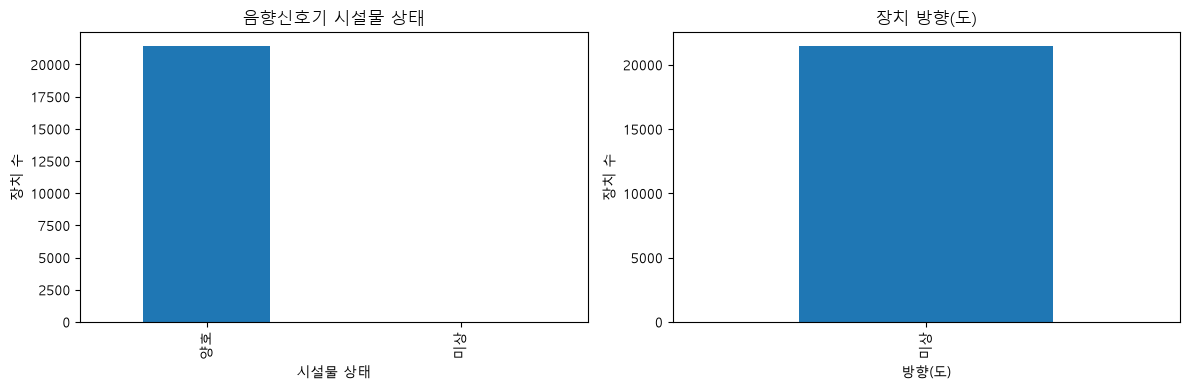

In [171]:
# 시설물 상태와 방향 분포를 각각 확인한다.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
audible_enriched['시설물상태'].value_counts(dropna=False).plot(kind='bar', ax=axes[0], title='음향신호기 시설물 상태')
axes[0].set_xlabel('시설물 상태')
axes[0].set_ylabel('장치 수')
audible_enriched['방향도'].value_counts(dropna=False).sort_index().plot(kind='bar', ax=axes[1], title='장치 방향(도)')
axes[1].set_xlabel('방향(도)')
axes[1].set_ylabel('장치 수')
plt.tight_layout()
plt.show()

### 음향신호기 원본 위치·상태 필드 확인

음향신호기 한 행은 한 장치의 레코드입니다. 원본에는 인프라 정보가 묶여 있지 않으며, 위치는 `XCE`, `YCE` 좌표와 `geometry`의 WKT `POINT (X Y)`로 중복 기록되어 있습니다. `XCE`, `YCE`는 경도·위도가 아니라 EPSG:5186의 미터 단위 투영좌표입니다.

`STAT_CDE` 등 코드 열의 정확한 의미(예: 정상 작동 여부)는 제공기관 코드북 없이 추정하지 않습니다. 아래에서 값 분포와 날짜를 확인하고, 코드북을 확보한 뒤에만 상태 변수로 사용합니다.

In [172]:
# 한 장치의 원본 위치 표현: XCE/YCE와 geometry의 POINT(X Y)는 같은 위치를 뜻한다.
position_fields = ['MGRNU', 'XCE', 'YCE', 'geometry', 'STAT_CDE', 'ESB_YMD', 'CAE_YMD', 'MK_CPY', 'WORK_CDE', 'VIEW_CDE']
display(audible[position_fields].head(10))
display(audible[['XCE', 'YCE']].describe())
print('XCE/YCE가 모두 있는 장치 수:', audible[['XCE', 'YCE']].dropna().shape[0])

,MGRNU,XCE,YCE,geometry,STAT_CDE,ESB_YMD,CAE_YMD,MK_CPY,WORK_CDE,VIEW_CDE
0,24-0000011058,187968.300000,549055.306244,POINT (187968.299999927 549055.306243806),1.0,20151026.0,20230102.0,대한신호,6,2
1,24-0000011081,186876.700000,551491.393744,POINT (186876.699999921 551491.393743825),1.0,20140808.0,20210720.0,대한신호,6,2
2,24-0000013895,185617.877085,548627.649122,POINT (185617.877084836 548627.649122097),1.0,20250409.0,20250409.0,대한신호,1,2
3,24-0000009872,185915.025000,544027.506243,POINT (185915.024999914 544027.506243215),1.0,20201102.0,20240621.0,대한신호,6,2
4,24-0000009871,185899.612500,544026.424993,POINT (185899.612499911 544026.424993082),1.0,20201102.0,20240621.0,대한신호,6,2
5,24-0000003730,188271.987500,544457.918743,POINT (188271.987499929 544457.91874327),1.0,20141231.0,20210701.0,신흥트래픽,6,2
6,24-0000008377,185677.962500,546833.681244,POINT (185677.962499912 546833.681243541),1.0,20151026.0,20240619.0,대한신호,6,2
7,24-0000013737,199787.843060,552544.101903,POINT (199787.843060111 552544.101903092),1.0,20170517.0,20170517.0,대한신호,1,2
8,24-0000013684,198798.250000,553059.956244,POINT (198798.249999994 553059.956244275),1.0,NaN,NaN,NaN,1,2
9,24-0000009124,194277.762500,552872.624994,POINT (194277.762499961 552872.624994),1.0,20130717.0,20201030.0,대한신호㈜,1,2


,XCE,YCE
count,16847.000000,16847.000000
mean,198711.034459,549719.046128
std,8401.214236,5792.941661
min,182282.836090,537384.118742
25%,191693.668750,544920.212517
50%,199176.500000,549644.043744
75%,205362.000000,553170.997381
max,216060.481582,565847.124880


XCE/YCE가 모두 있는 장치 수: 16847


In [173]:
# 상태/설치 이력으로 보이는 원본 코드와 날짜의 분포
for column in ['STAT_CDE', 'WORK_CDE', 'VIEW_CDE', 'DRN_CDE', 'ESB_YMD', 'CAE_YMD']:
    print(f'\n[{column}]')
    display(audible[column].value_counts(dropna=False).head(20).rename('count').to_frame())


[STAT_CDE]


,count
STAT_CDE,
1.0,21426
NaN,25



[WORK_CDE]


,count
WORK_CDE,
1,18958
6,2322
3,171



[VIEW_CDE]


...

,count
DRN_CDE,
180.0,10536
NaN,9314
0.0,1030
45.0,208
90.0,123
270.0,83
135.0,71
315.0,59
225.0,27



[ESB_YMD]


,count
ESB_YMD,
NaN,838
20070601.0,813
20000101.0,503
20201030.0,119
20241130.0,118
20201123.0,117
20080101.0,116
20161231.0,113
20250210.0,97



[CAE_YMD]


,count
CAE_YMD,
NaN,890
20000101.0,208
20241130.0,206
20070601.0,137
20251015.0,132
20240731.0,110
20201123.0,106
20251130.0,106
20241113.0,105


In [174]:
# 2) 장애인편의시설 목록
facility = read_csv_flexible(DATASETS['facility'])
facility_summary = profile(facility, '장애인편의시설')

서울시_장애인편의시설_목록정보(한국사회보장정보원)_.csv: encoding=cp949, rows=29,153, cols=12

[장애인편의시설] shape=(29153, 12), duplicate rows=0


,dtype,missing_n,missing_pct,nunique
시설대표자성명,float64,29153,100.0,0
순번,int64,0,0.0,29153
시설기본주소,str,0,0.0,28751
시설ID,str,0,0.0,28684
시설위도,float64,0,0.0,23589
시설경도,float64,0,0.0,23492
시설명,str,0,0.0,19208
설립일자,int64,0,0.0,6116
시설유형,str,0,0.0,67
영업상태구분코드,str,0,0.0,1


,설립일자,순번,시설위도,시설경도,시설명,시설대표자성명,시설유형,시설기본주소,영업상태구분코드,영업상태구분명,복지로관리시설구분코드,시설ID
0,20120130,20155836847,0.000000,0.000000,서울강동초등학교 다목적강당,NaN,초등학교,서울 강동구 상암로14길 77,Y,영업,17,1174011000-1-03060000
1,20010910,20155836848,37.547399,127.146421,명성교회 월드글로리아센터,NaN,대피소,서울 강동구 양재대로134길 52(명일동),Y,영업,17,1174010100-1-03400001
2,20170425,20155836852,0.000000,0.000000,수유역두산위브아파트1-번1동,NaN,대피소,서울 강북구 덕릉로41길 12,Y,영업,17,KODIX-SL-0000001


In [175]:
facility.columns

Index(['설립일자', '순번', '시설위도', '시설경도', '시설명', '시설대표자성명', '시설유형', '시설기본주소',
       '영업상태구분코드', '영업상태구분명', '복지로관리시설구분코드', '시설ID'],
      dtype='str')

In [176]:
# 시설유형 컬럼 구성 확인
facility_type_counts = facility['시설유형'].value_counts(dropna=False).rename_axis('시설유형').to_frame('건수')
print('시설유형 고유값 수:', facility['시설유형'].nunique(dropna=False))
display(facility_type_counts)

시설유형 고유값 수: 67


,건수
시설유형,
다세대주택,15471
아파트,3652
금융업소 등 일반업무시설,2508
일반음식점,754
연립주택,601
...,...
전신전화국,1
한국장애인고용공단 및 지사,1
봉안당(종교시설에 해당하는 것은 제외),1


In [177]:
# ���������� ���� ���� ������ Ȯ��: ���� ���� ������ ������ �����ϴ�.
if 'subway_voice' not in globals():
    subway_voice = read_csv_flexible(DATASETS['subway_voice'])

In [178]:
# 역명에 (9)가 포함된 데이터 확인
station_9 = subway_voice[subway_voice['역명'].astype(str).str.contains(r'\(9\)', na=False)]
print("역명에 '(9)'가 포함된 데이터 건수:", len(station_9))
print('현재 데이터에 포함된 호선:', sorted(subway_voice['호선'].dropna().astype(str).unique()))
display(station_9[['호선', '외부역번호', '역명']].drop_duplicates())

역명에 '(9)'가 포함된 데이터 건수: 0
현재 데이터에 포함된 호선: ['1', '2', '3', '4', '5', '6', '7', '8']


,호선,외부역번호,역명


In [179]:
# 3) 지하철 시각장애인 음성유도기 설치 위치
subway_voice = read_csv_flexible(DATASETS['subway_voice'])
subway_voice_summary = profile(subway_voice, '지하철 음성유도기')

서울교통공사_지하철_시각장애인_음성유도기_설치_위치_정보_20260213.csv: encoding=cp949, rows=5,802, cols=5

[지하철 음성유도기] shape=(5802, 5), duplicate rows=0


,dtype,missing_n,missing_pct,nunique
연번,int64,0,0.0,5802
설치위치,str,0,0.0,3974
외부역번호,int64,0,0.0,245
역명,str,0,0.0,226
호선,int64,0,0.0,8


,연번,호선,외부역번호,역명,설치위치
0,1,1,133,서울역 (1),4호선 환승통로출구
1,2,1,133,서울역 (1),서울역측 개표소
2,3,1,133,서울역 (1),서울역측 발매기 앞 천장(142번 발매기 위)


In [180]:
subway_voice.columns

Index(['연번', '호선', '외부역번호', '역명', '설치위치'], dtype='str')

In [181]:
# 4) 보행자 사고 다발지역
accident = read_csv_flexible(DATASETS['accident'])
accident_summary = profile(accident, '보행자 사고 다발지역')

보행자_사고_다발지역.csv: encoding=cp949, rows=2,402, cols=15

[보행자 사고 다발지역] shape=(2402, 15), duplicate rows=0


,dtype,missing_n,missing_pct,nunique
사고다발지fid,int64,0,0.0,2402
다발지역폴리곤,str,0,0.0,2328
경도,float64,0,0.0,2297
위도,float64,0,0.0,2297
지점명,str,0,0.0,1900
시도시군구명,str,0,0.0,1270
지점코드,int64,0,0.0,788
법정동코드,int64,0,0.0,713
사상자수,int64,0,0.0,21
중상자수,int64,0,0.0,19


,사고다발지fid,사고다발지id,법정동코드,지점코드,시도시군구명,지점명,사고건수,사상자수,사망자수,중상자수,경상자수,부상신고자수,경도,위도,다발지역폴리곤
0,6778887,2022040,1111017100,11110001,서울특별시 종로구1,서울특별시 종로구 명륜2가(성균관대입구교차로 부근),9,10,1,9,0,0,126.998780,37.582940,"{""type"":""Polygon"",""coordinates"":[[[126.9996779..."
1,6779548,2022040,1111013700,11110002,서울특별시 종로구2,서울특별시 종로구 낙원동(낙원상가 부근),8,8,0,8,0,0,126.988435,37.571899,"{""type"":""Polygon"",""coordinates"":[[[126.9893336..."
2,6779517,2022040,1111011900,11110003,서울특별시 종로구3,서울특별시 종로구 세종로(세종로180 부근),7,8,0,8,0,0,126.976899,37.569865,"{""type"":""Polygon"",""coordinates"":[[[126.9777971..."


In [182]:
accident.columns

Index(['사고다발지fid', '사고다발지id', '법정동코드', '지점코드', '시도시군구명', '지점명', '사고건수', '사상자수',
       '사망자수', '중상자수', '경상자수', '부상신고자수', '경도', '위도', '다발지역폴리곤'],
      dtype='str')

In [183]:
# 사고 관련 핵심 컬럼만 관찰
from pathlib import Path
import pandas as pd
accident_path = Path('DartB_TOYPROJECT') / '보행자_사고_다발지역.csv'
if not accident_path.exists():
    accident_path = Path.cwd() / '보행자_사고_다발지역.csv'
accident = pd.read_csv(accident_path, encoding='cp949')
accident_metric_cols = [
    '사고건수', '사상자수', '사망자수',
    '중상자수', '경상자수', '부상신고자수'
]
display(accident[accident_metric_cols].head(20))
display(accident[accident_metric_cols].describe().T)

,사고건수,사상자수,사망자수,중상자수,경상자수,부상신고자수
0,9,10,1,9,0,0
1,8,8,0,8,0,0
2,7,8,0,8,0,0
3,7,8,0,7,1,0
4,7,8,0,7,0,1
5,7,7,0,7,0,0
6,9,9,1,8,0,0
7,8,10,0,9,0,1
8,8,9,0,9,0,0
9,8,8,0,8,0,0


,count,mean,std,min,25%,50%,75%,max
사고건수,2402.0,7.983347,1.703970,7.0,7.0,7.0,8.0,22.0
사상자수,2402.0,8.493755,2.221436,7.0,7.0,8.0,9.0,34.0
사망자수,2402.0,0.302248,0.574542,0.0,0.0,0.0,1.0,5.0
중상자수,2402.0,7.898834,1.891080,4.0,7.0,7.0,8.0,22.0
경상자수,2402.0,0.260616,0.931394,0.0,0.0,0.0,0.0,20.0
부상신고자수,2402.0,0.032057,0.206649,0.0,0.0,0.0,0.0,5.0


In [184]:
# 사고 관련 컬럼 간 관계 확인
detail_cols = ['사망자수', '중상자수', '경상자수', '부상신고자수']
metric_data = accident[accident_metric_cols].apply(pd.to_numeric, errors='coerce')
detail_sum = metric_data[detail_cols].sum(axis=1)
print('사상자수 = 세부 피해자 수 합계 일치 여부:', bool(metric_data['사상자수'].eq(detail_sum).all()))
print('일치하지 않는 행 수:', int(metric_data['사상자수'].ne(detail_sum).sum()))
print('\n[기술통계]')
display(metric_data.describe().T.round(3))
print('\n[상관관계]')
display(metric_data.corr().round(3))

사상자수 = 세부 피해자 수 합계 일치 여부: True
일치하지 않는 행 수: 0

[기술통계]


,count,mean,std,min,25%,50%,75%,max
사고건수,2402.0,7.983,1.704,7.0,7.0,7.0,8.0,22.0
사상자수,2402.0,8.494,2.221,7.0,7.0,8.0,9.0,34.0
사망자수,2402.0,0.302,0.575,0.0,0.0,0.0,1.0,5.0
중상자수,2402.0,7.899,1.891,4.0,7.0,7.0,8.0,22.0
경상자수,2402.0,0.261,0.931,0.0,0.0,0.0,0.0,20.0
부상신고자수,2402.0,0.032,0.207,0.0,0.0,0.0,0.0,5.0



[상관관계]


,사고건수,사상자수,사망자수,중상자수,경상자수,부상신고자수
사고건수,1.000,0.792,0.032,0.909,0.024,-0.001
사상자수,0.792,1.000,0.137,0.834,0.552,0.252
사망자수,0.032,0.137,1.000,-0.206,0.119,0.041
중상자수,0.909,0.834,-0.206,1.000,0.083,0.010
경상자수,0.024,0.552,0.119,0.083,1.000,0.333
부상신고자수,-0.001,0.252,0.041,0.010,0.333,1.000


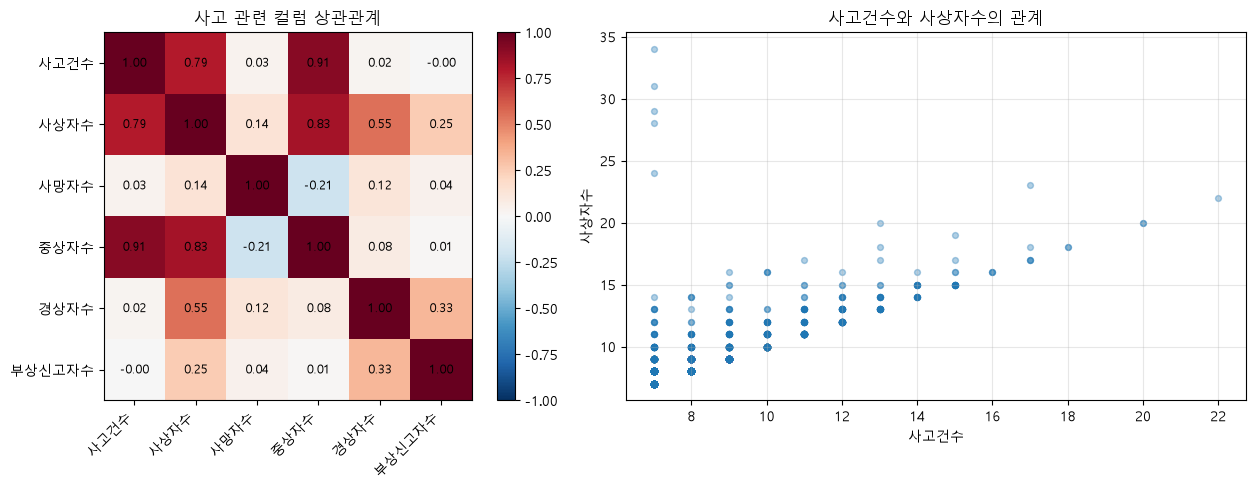

In [185]:
# 사고 관련 컬럼 간단 시각화
corr = metric_data.corr()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xticks(range(len(corr.columns)))
axes[0].set_yticks(range(len(corr.columns)))
axes[0].set_xticklabels(corr.columns, rotation=45, ha='right')
axes[0].set_yticklabels(corr.columns)
axes[0].set_title('사고 관련 컬럼 상관관계')
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        axes[0].text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].scatter(metric_data['사고건수'], metric_data['사상자수'], alpha=0.35, s=18)
axes[1].set_title('사고건수와 사상자수의 관계')
axes[1].set_xlabel('사고건수')
axes[1].set_ylabel('사상자수')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 사고 관련 분석 결과 요약

- `사상자수`는 `사망자수 + 중상자수 + 경상자수 + 부상신고자수`의 합계이다. 따라서 심각도 지표를 만들 때 `사상자수`와 세부 항목을 함께 사용하면 중복 계산이 발생한다.
- `사고건수`와 `사상자수`는 양의 상관관계를 보이며, 특히 `사고건수`와 `중상자수`의 관계가 강하다.
- `사망자수`는 발생 빈도는 낮지만 심각도가 매우 높으므로 별도의 높은 가중치를 주는 것이 적절하다.

### 사고 심각도 지표 구성 방향

`사망자수`, `중상자수`, `경상자수`, `부상신고자수`에 서로 다른 가중치를 적용해 심각도 점수를 만들 수 있다. 사망자와 중상자에 높은 가중치를 주고, 이후 점수를 0~1 범위로 정규화하는 방식을 우선 검토한다.

### 구간 난이도 활용 방향

사고다발지역을 보행 네트워크의 도로 구간에 연결한 뒤, 각 구간의 사고 심각도 점수를 합산하거나 평균내어 구간 난이도에 반영할 수 있다. 최종적으로는 사고 심각도에 경사도, 사고다발지역과의 거리, 보행 인프라 부족 등을 함께 반영한다. 사고건수는 교통량과 구간 길이의 영향을 받으므로 추후 가능하면 교통량·보행량·구간 길이로 보정한다.

## 1. 좌표 데이터 정리 및 대상 권역 필터링

음향신호기 원본의 `XCE`, `YCE`는 WGS84 경위도가 아니라 EPSG:5186 투영좌표입니다. 동봉된 shapefile의 `.prj`를 기준으로 좌표계를 지정한 뒤 EPSG:4326으로 변환합니다.

시설 및 사고 데이터의 위도·경도는 숫자로 변환하고, 범위를 벗어난 값(예: 시설 위도·경도 `0, 0`)을 제외합니다. 대상 권역 여부는 중심점에서의 직선거리로 우선 확인합니다. 실제 edge 결합에서는 이후 보행 네트워크까지의 거리도 별도로 검증해야 합니다.

In [186]:
# EPSG:5186 = KGD2002 / Central Belt 2010 (음향신호기 shapefile .prj와 일치)
audible_enriched['XCE'] = pd.to_numeric(audible_enriched['XCE'], errors='coerce')
audible_enriched['YCE'] = pd.to_numeric(audible_enriched['YCE'], errors='coerce')
audible_geo = gpd.GeoDataFrame(
    audible_enriched.dropna(subset=['XCE', 'YCE']).copy(),
    geometry=gpd.points_from_xy(audible_enriched.dropna(subset=['XCE', 'YCE'])['XCE'], audible_enriched.dropna(subset=['XCE', 'YCE'])['YCE']),
    crs='EPSG:5186',
).to_crs('EPSG:4326')

facility['시설위도'] = pd.to_numeric(facility['시설위도'], errors='coerce')
facility['시설경도'] = pd.to_numeric(facility['시설경도'], errors='coerce')
facility_geo = gpd.GeoDataFrame(
    facility.loc[facility['시설위도'].between(33, 39) & facility['시설경도'].between(124, 132)].copy(),
    geometry=gpd.points_from_xy(
        facility.loc[facility['시설위도'].between(33, 39) & facility['시설경도'].between(124, 132), '시설경도'],
        facility.loc[facility['시설위도'].between(33, 39) & facility['시설경도'].between(124, 132), '시설위도'],
    ),
    crs='EPSG:4326',
)

accident['위도'] = pd.to_numeric(accident['위도'], errors='coerce')
accident['경도'] = pd.to_numeric(accident['경도'], errors='coerce')
accident_geo = gpd.GeoDataFrame(
    accident.dropna(subset=['위도', '경도']).copy(),
    geometry=gpd.points_from_xy(accident.dropna(subset=['위도', '경도'])['경도'], accident.dropna(subset=['위도', '경도'])['위도']),
    crs='EPSG:4326',
)

center = gpd.GeoDataFrame(geometry=[Point(CENTER_LON, CENTER_LAT)], crs='EPSG:4326').to_crs('EPSG:5186')
def add_center_distance(gdf):
    projected = gdf.to_crs('EPSG:5186').copy()
    projected['center_distance_m'] = projected.geometry.distance(center.geometry.iloc[0])
    return projected.to_crs('EPSG:4326')

audible_geo = add_center_distance(audible_geo)
facility_geo = add_center_distance(facility_geo)
accident_geo = add_center_distance(accident_geo)

nearby_audible = audible_geo.query('center_distance_m <= @RADIUS_M').copy()
nearby_facility = facility_geo.query('center_distance_m <= @RADIUS_M').copy()
nearby_accident = accident_geo.query('center_distance_m <= @RADIUS_M').copy()

pd.DataFrame({
    'dataset': ['음향신호기', '장애인편의시설', '보행자 사고 다발지역'],
    'valid_coordinate_rows': [len(audible_geo), len(facility_geo), len(accident_geo)],
    f'within_{RADIUS_M}m': [len(nearby_audible), len(nearby_facility), len(nearby_accident)],
})

,dataset,valid_coordinate_rows,within_800m
0,음향신호기,16847,69
1,장애인편의시설,24075,216
2,보행자 사고 다발지역,2402,5


### 음향신호기 위치를 WGS84와 인프라 기준으로 보기

아래 표에서는 변환 후의 경도·위도와 기준점으로부터의 거리를 확인합니다. 이어지는 표는 각 음향신호기에서 가장 가까운 Kakao 인프라를 **참고용으로만** 연결합니다. 원본 음향신호기 데이터에 인프라가 공식적으로 연결되어 있는 것은 아니며, 이 거리는 장치가 해당 시설을 위한 것이라는 증거가 아닙니다.

In [187]:
audible_geo['longitude'] = audible_geo.geometry.x
audible_geo['latitude'] = audible_geo.geometry.y
nearby_audible = audible_geo.query('center_distance_m <= @RADIUS_M').copy()
display(nearby_audible[['MGRNU', 'longitude', 'latitude', 'center_distance_m', '음향신호기종류', '시설물상태', '표출구분', '작업단계', '방향도', '상태_지원점수_제안', '상태_경고']].sort_values('center_distance_m').head(20))

,MGRNU,longitude,latitude,center_distance_m,음향신호기종류,시설물상태,표출구분,작업단계,방향도,상태_지원점수_제안,상태_경고
8292,24-0000009480,126.953694,37.504966,292.116370,버튼식,양호,보기,자료입력,미상,1.0,경고 없음
16825,24-0000018368,126.953644,37.504913,295.612125,버튼식,양호,보기,자료입력,미상,1.0,경고 없음
5190,24-0000009751,126.954213,37.503033,296.839578,버튼식,양호,보기,검증완료,미상,1.0,경고 없음
19000,24-0000009481,126.953644,37.505055,298.080829,버튼식,양호,보기,검증완료,미상,1.0,경고 없음
5191,24-0000009752,126.954265,37.502912,301.090213,버튼식,양호,보기,검증완료,미상,1.0,경고 없음
19001,24-0000018369,126.953480,37.504945,310.517080,버튼식,양호,보기,자료입력,미상,1.0,경고 없음
16954,24-0000018389,126.953369,37.504970,320.609447,버튼식,양호,보기,자료입력,미상,1.0,경고 없음
16955,24-0000018388,126.953356,37.505027,322.657996,버튼식,양호,보기,자료입력,미상,1.0,경고 없음
14142,24-0000016011,126.960705,37.504060,335.946494,버튼식,양호,보기,자료입력,미상,1.0,경고 없음
14143,24-0000016012,126.960725,37.504095,337.068761,버튼식,양호,보기,자료입력,미상,1.0,경고 없음


In [188]:
# 중앙대 정문 800m 권역의 상태는 전체 서울 분포와 분리해서 확인한다.
nearby_status_summary = (nearby_audible.groupby(['시설물상태', '상태_경고'], dropna=False)
                         .agg(장치수=('MGRNU', 'size'), 평균_기준점거리_m=('center_distance_m', 'mean'))
                         .reset_index().sort_values('장치수', ascending=False))
display(nearby_status_summary)

nearby_good_rate = (nearby_audible['시설물상태'].eq('양호').mean() * 100) if len(nearby_audible) else float('nan')
print(f'대상 권역 음향신호기 수: {len(nearby_audible):,}개')
print(f'그중 시설물 상태가 양호인 비율: {nearby_good_rate:.1f}%')

,시설물상태,상태_경고,장치수,평균_기준점거리_m
0,양호,경고 없음,69,577.130512


대상 권역 음향신호기 수: 69개
그중 시설물 상태가 양호인 비율: 100.0%


In [189]:
# 가장 가까운 수집 인프라를 참고용으로 찾는다. 이는 원본의 공식 연결 관계가 아니다.
infra = pd.read_csv(PROJECT_DIR / 'data' / 'infra_snapped.csv')
infra_geo = gpd.GeoDataFrame(
    infra,
    geometry=gpd.points_from_xy(pd.to_numeric(infra['x']), pd.to_numeric(infra['y'])),
    crs='EPSG:4326',
).to_crs('EPSG:5186')
nearest_infra = gpd.sjoin_nearest(
    nearby_audible.to_crs('EPSG:5186'),
    infra_geo[['place_name', 'category_group_name', 'geometry']],
    how='left',
    distance_col='nearest_infra_distance_m',
).to_crs('EPSG:4326')
display(nearest_infra[['MGRNU', 'longitude', 'latitude', 'place_name', 'category_group_name', 'nearest_infra_distance_m']].sort_values('nearest_infra_distance_m').head(30))

,MGRNU,longitude,latitude,place_name,category_group_name,nearest_infra_distance_m
14789,24-0000016034,126.961620,37.508737,교촌치킨 흑석1호점,음식점,5.228715
14790,24-0000016033,126.961682,37.508784,교촌치킨 흑석1호점,음식점,8.928542
2822,24-0000002406,126.949419,37.504258,우드오븐,카페,9.252699
16955,24-0000018388,126.953356,37.505027,뜸들이다 상도점,음식점,9.605590
19000,24-0000009481,126.953644,37.505055,매머드익스프레스 중앙대후문점,카페,10.584665
19000,24-0000009481,126.953644,37.505055,샐러디 중앙대점,음식점,10.584665
2821,24-0000002403,126.949695,37.504114,명랑핫도그 상도점,음식점,10.897051
16954,24-0000018389,126.953369,37.504970,무음,음식점,10.907931
14792,24-0000016031,126.961877,37.508917,팔당장어 흑석점,음식점,10.958485
14787,24-0000016036,126.961501,37.508900,홍루이젠 흑석중앙대점,음식점,11.121017


### 노드·edge 난이도에 쓰는 방법

음향신호기는 인프라 POI에 붙이는 값이 아니라, **교차로 부근의 보행 환경을 설명하는 점 데이터**로 다루는 것이 적절합니다. 다음 단계에서는 각 음향신호기를 보행 그래프의 가장 가까운 crossing node 또는 edge에 스냅하고, 스냅 거리도 함께 저장합니다.

#### 1) edge 연결 규칙(다음 구현 단계)

- 각 장치를 가장 가까운 **crossing node 우선**, 없으면 가장 가까운 보행 edge에 스냅합니다. `signal_snap_distance_m`을 반드시 저장하고, 예를 들어 20m를 넘는 연결은 `spatial_match_uncertain=1`로 별도 표기합니다. 20m는 시작용 기준이며 지도 검토 후 조정합니다.
- edge에는 `audible_signal_count`, `audible_signal_good_count`, `audible_signal_damaged_count`, `audible_signal_aged_count`, `audible_signal_unknown_count`를 따로 저장합니다. 서로 상쇄해 하나의 숫자로 먼저 뭉개지 않습니다.
- `DRN_CDE`의 방향도는 나중에 edge 진행방향 또는 횡단 방향과 비교합니다. 방향이 맞는 장치만 해당 횡단 movement의 보조 신호로 인정할 수 있습니다. 현재 그래프가 양방향 edge를 가지므로 이 비교는 경로 방향을 고려해 구현합니다.

#### 2) 상태 중심 난이도 반영 제안

음향신호기는 경사처럼 불편을 만드는 요인이 아니라, 교차로에서 길찾기를 돕는 **지원 인프라**입니다. 따라서 난이도에 무조건 가산하지 않고, 아래처럼 `지원 효과`와 `유지보수 위험`을 분리합니다.

| 시설물 상태 | edge 기록 | 난이도에 대한 초기 제안 |
| --- | --- | --- |
| 양호 | `good_count += 1` | 교차로 난이도를 소폭 낮출 수 있는 확정 지원 증거 |
| 파손 | `damaged_count += 1` | 지원 효과는 주지 않고, 유지보수 위험 플래그를 추가 |
| 도색 | `paint_count += 1` | 작동 불능으로 단정하지 않으며, 중립·점검 필요로 기록 |
| 노후 | `aged_count += 1` | 지원 효과를 낮추거나 중립으로 두고, 점검 필요 플래그 추가 |
| 미상 또는 장치 없음 | `unknown` | 불리한 점수를 주지 않음. 데이터 미확인과 실제 부재를 구분 |

MVP 점수는 `edge_difficulty = slope_component + crossing_risk_component - audible_support_component + maintenance_warning_component`처럼 설계할 수 있습니다. 여기서 `audible_support_component`는 양호 장치가 해당 crossing에 신뢰도 높게 스냅됐을 때만 작동하고, `maintenance_warning_component`는 파손·노후 장치가 있을 때 별도의 경고 또는 작은 가산값으로 사용합니다. 가중치는 사용자 검토와 현장 검증 전에는 고정하지 않습니다.

`WORK_CDE`는 장치 품질이 아니라 데이터 처리 단계이므로, 난이도 항이 아닌 `data_confidence`에 쓰는 편이 안전합니다. 예를 들어 검증완료·승인·경찰청승인 상태의 레코드는 공간 매칭 결과의 신뢰도 표시를 높이는 데 활용할 수 있습니다.

,count
시설유형,
다세대주택,129
아파트,35
대피소,13
종교집회장,7
노인복지시설,5
어린이집,4
초등학교,3
수퍼마켓?일용품 등의 소매점,3
일반음식점,3


,지점명,사고건수,사상자수,사망자수,중상자수,경상자수,부상신고자수,center_distance_m
1175,서울 동작구 흑석동(소망메디컬약국 부근),15,15,0,15,0,0,519.065017
1623,서울 동작구 흑석동(흑석시장 부근),12,12,0,12,0,0,563.619402
710,서울 동작구 흑석동(김연두내과의원 부근),12,12,1,11,0,0,495.099013
2061,서울 동작구 흑석동(신세명약국 부근),11,11,0,11,0,0,571.507214
144,서울특별시 동작구 흑석동(명수대상가 부근),7,7,1,6,0,0,510.883971


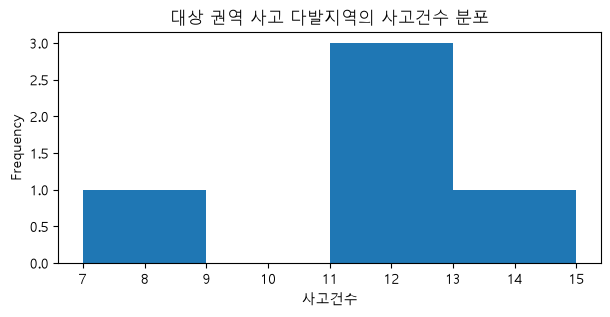

In [190]:
# 대상 권역의 시설 유형과 사고 심각도 분포
display(nearby_facility['시설유형'].value_counts().head(20).rename('count').to_frame())

accident_metrics = ['사고건수', '사상자수', '사망자수', '중상자수', '경상자수', '부상신고자수']
for col in accident_metrics:
    nearby_accident[col] = pd.to_numeric(nearby_accident[col], errors='coerce')
display(nearby_accident[['지점명', *accident_metrics, 'center_distance_m']].sort_values('사고건수', ascending=False))

if len(nearby_accident):
    nearby_accident['사고건수'].plot(kind='hist', bins=min(15, nearby_accident['사고건수'].nunique()), figsize=(7, 3), title='대상 권역 사고 다발지역의 사고건수 분포')
    plt.xlabel('사고건수')
    plt.show()

## 2. 지도에서 공간 범위 확인

원은 800m 참고 범위입니다. 점이 원 안에 있다고 해서 즉시 보행 edge에 연결 가능한 것은 아닙니다. 이후 단계에서 각각을 `pedestrian_graph_with_slope.graphml`의 가장 가까운 edge 또는 node에 스냅하고, 스냅 거리가 큰 항목은 신뢰도 경고 대상으로 남깁니다.

사고 다발지역 폴리곤은 원본 GeoJSON 문자열을 파싱할 수 있는 행만 반투명하게 표시합니다.

In [191]:
m = folium.Map(location=[CENTER_LAT, CENTER_LON], zoom_start=15, tiles='OpenStreetMap')
folium.Marker([CENTER_LAT, CENTER_LON], tooltip='중앙대 정문 기준점', icon=folium.Icon(color='red')).add_to(m)
folium.Circle([CENTER_LAT, CENTER_LON], radius=RADIUS_M, color='#2563eb', fill=False, tooltip='800m 참고 범위').add_to(m)

signal_color = {'양호': '#16a34a', '파손': '#dc2626', '도색': '#f59e0b', '노후': '#7c3aed', '미상': '#6b7280'}
for _, row in nearby_audible.iterrows():
    status = row['시설물상태']
    tooltip = f"음향신호기 | {status} | 방향 {row['방향도']}도 | {row['상태_경고']}"
    folium.CircleMarker(
        [row.geometry.y, row.geometry.x], radius=4, color=signal_color.get(status, '#6b7280'),
        fill=True, fill_opacity=0.9, tooltip=tooltip
    ).add_to(m)

for _, row in nearby_facility.iterrows():
    label = f"{row['시설명']} ({row['시설유형']})"
    folium.CircleMarker([row.geometry.y, row.geometry.x], radius=3, color='#7c3aed', fill=True, tooltip=label).add_to(m)

for _, row in nearby_accident.iterrows():
    tooltip = f"{row['지점명']} | 사고 {row['사고건수']}건"
    folium.CircleMarker([row.geometry.y, row.geometry.x], radius=5, color='#dc2626', fill=True, fill_opacity=0.8, tooltip=tooltip).add_to(m)
    try:
        polygon = shape(json.loads(row['다발지역폴리곤']))
        folium.GeoJson(polygon.__geo_interface__, style_function=lambda _: {'color': '#dc2626', 'weight': 1, 'fillOpacity': 0.12}).add_to(m)
    except (TypeError, ValueError, KeyError):
        pass

from IPython.display import HTML, IFrame
HTML(m.get_root().render())
IFrame(src='http://localhost:8000/', width='100%', height=700)

### 지도 결과와 경사도·보행 인프라를 결합하면 무엇을 알 수 있나?

앞의 지도는 중심점에서 800m 안에 어떤 시설과 사고 다발지역이 있는지를 보여주는 공간 범위 확인 단계입니다. 최종 분석에서는 여기에 보행 네트워크의 경사도(`slope_pct`)를 결합해, 점·폴리곤 단위의 정보를 실제 보행 구간(edge) 단위로 연결합니다.

궁극적으로 만들고 싶은 결과물은 단순한 위치 지도보다, 어떤 보행 구간이 이동하기 어렵고 개선 우선순위가 높은지 보여주는 보행 접근성·안전 지도입니다. 경사가 급하고 사고 위험이 높으며 지원시설이 부족한 구간은 우선 개선 후보로 볼 수 있고, 반대로 경사가 완만하고 지원시설이 가까운 구간은 상대적으로 이용하기 좋은 경로로 평가할 수 있습니다.

아래 셀은 이 방향을 보여주는 MVP 예시입니다. 실제 정책 점수로 확정하는 단계가 아니라, 각 edge에 경사도·사고·음향 신호기·편의시설 정보를 붙이고 우선순위 점수를 계산하는 결합 구조를 확인하는 단계입니다.

In [192]:
import networkx as nx
import numpy as np
from shapely.geometry import LineString

# 경사도가 포함된 보행 네트워크를 불러와 edge GeoDataFrame으로 변환
graph_path = PROJECT_DIR / 'data' / 'pedestrian_graph_with_slope.graphml'
G = nx.read_graphml(graph_path)
edge_rows = []
for u, v, key, data in G.edges(keys=True, data=True):
    u_node, v_node = G.nodes[u], G.nodes[v]
    if not all(k in u_node and k in v_node for k in ('x', 'y')):
        continue
    record = dict(data)
    record.update({
        'edge_id': f'{u}|{v}|{key}',
        'u': u, 'v': v, 'key': key,
        'geometry': LineString([(float(u_node['x']), float(u_node['y'])),
                                 (float(v_node['x']), float(v_node['y']))]),
    })
    edge_rows.append(record)

edges = gpd.GeoDataFrame(edge_rows, geometry='geometry', crs='EPSG:4326')
edges['length_m'] = pd.to_numeric(edges.get('length'), errors='coerce')
edges['slope_pct'] = pd.to_numeric(edges.get('slope_pct'), errors='coerce').fillna(0)
edges_proj = edges.to_crs('EPSG:5186')

def attach_nearest_count(edge_frame, points, prefix, max_distance_m=30):
    """가까운 점 데이터의 개수와 최소 거리를 edge에 결합한다."""
    points_proj = points[['geometry']].dropna().to_crs('EPSG:5186')
    joined = gpd.sjoin_nearest(
        edge_frame[['edge_id', 'geometry']], points_proj,
        how='left', max_distance=max_distance_m,
        distance_col=f'{prefix}_distance_m',
    )
    matched = joined.dropna(subset=['index_right'])
    if matched.empty:
        summary = pd.DataFrame(index=edge_frame['edge_id'])
    else:
        summary = matched.groupby('edge_id').agg(
            **{
                f'{prefix}_count': ('index_right', 'size'),
                f'{prefix}_distance_m': (f'{prefix}_distance_m', 'min'),
            }
        )
    result = edge_frame.set_index('edge_id').join(summary).reset_index()
    result[f'{prefix}_count'] = result[f'{prefix}_count'].fillna(0).astype(int)
    result[f'{prefix}_distance_m'] = result[f'{prefix}_distance_m'].fillna(np.inf)
    return result

# 앞 단계 셀을 건너뛰고 이 셀만 실행해도 분석 대상 범위를 준비한다.
if 'nearby_audible' not in globals():
    nearby_audible = audible_geo.query('center_distance_m <= @RADIUS_M').copy()
if 'nearby_facility' not in globals():
    nearby_facility = facility_geo.query('center_distance_m <= @RADIUS_M').copy()
if 'nearby_accident' not in globals():
    nearby_accident = accident_geo.query('center_distance_m <= @RADIUS_M').copy()

edge_context = edges_proj
edge_context = attach_nearest_count(edge_context, nearby_audible, 'audible')
edge_context = attach_nearest_count(edge_context, nearby_facility, 'facility')
edge_context = attach_nearest_count(edge_context, nearby_accident, 'accident')

# 설명용 MVP 점수: 숫자가 높을수록 개선 우선순위가 높은 구간
edge_context['slope_component'] = np.clip(edge_context['slope_pct'].abs() / 8, 0, 1) * 4
edge_context['accident_risk_component'] = np.clip(edge_context['accident_count'] / 3, 0, 3)
edge_context['audible_support_component'] = np.where(edge_context['audible_count'] > 0, 1.5, 0)
edge_context['facility_support_component'] = np.clip(edge_context['facility_count'] / 3, 0, 1)
edge_context['priority_score'] = (
    edge_context['slope_component']
    + edge_context['accident_risk_component']
    - edge_context['audible_support_component']
    - edge_context['facility_support_component']
)

display(edge_context[['edge_id', 'length_m', 'slope_pct', 'audible_count',
                      'facility_count', 'accident_count', 'priority_score']]
        .sort_values('priority_score', ascending=False).head(20))

# 최종 결과: 우선순위가 높은 보행 edge를 붉게 표시하는 지도
from branca.colormap import linear

edge_map = edge_context[['edge_id', 'length_m', 'slope_pct', 'audible_count',
                        'facility_count', 'accident_count', 'priority_score',
                        'geometry']].to_crs('EPSG:4326')
score_min = float(edge_map['priority_score'].min())
score_max = float(edge_map['priority_score'].max())
if score_min == score_max:
    score_max = score_min + 1
score_color = linear.YlOrRd_09.scale(score_min, score_max)

priority_map = folium.Map(
    location=[CENTER_LAT, CENTER_LON], zoom_start=15, tiles='OpenStreetMap'
)
folium.Marker([CENTER_LAT, CENTER_LON], tooltip='분석 중심점',
              icon=folium.Icon(color='blue')).add_to(priority_map)
folium.Circle([CENTER_LAT, CENTER_LON], radius=RADIUS_M, color='#2563eb',
              fill=False, tooltip='분석 범위 800m').add_to(priority_map)

folium.GeoJson(
    edge_map.to_json(),
    name='보행 edge 우선순위',
    style_function=lambda feature: {
        'color': score_color(feature['properties']['priority_score']),
        'weight': 5, 'opacity': 0.85,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['edge_id', 'slope_pct', 'audible_count', 'facility_count',
                'accident_count', 'priority_score'],
        aliases=['edge', '경사도(%)', '음향 신호기 수', '편의시설 수',
                 '사고 지점 수', '개선 우선순위'],
        localize=True, sticky=False, labels=True,
    ),
).add_to(priority_map)

for _, row in nearby_audible.to_crs('EPSG:4326').iterrows():
    folium.CircleMarker([row.geometry.y, row.geometry.x], radius=4,
                        color='#16a34a', fill=True, tooltip='음향 신호기').add_to(priority_map)
for _, row in nearby_facility.to_crs('EPSG:4326').iterrows():
    folium.CircleMarker([row.geometry.y, row.geometry.x], radius=3,
                        color='#7c3aed', fill=True, tooltip='장애인 편의시설').add_to(priority_map)
for _, row in nearby_accident.to_crs('EPSG:4326').iterrows():
    folium.CircleMarker([row.geometry.y, row.geometry.x], radius=5,
                        color='#dc2626', fill=True, tooltip='사고 지점').add_to(priority_map)

score_color.caption = '보행 edge 개선 우선순위(높을수록 우선)'
score_color.add_to(priority_map)
from IPython.display import HTML, IFrame
HTML(priority_map.get_root().render())
IFrame(src='http://localhost:8000/', width='100%', height=700)

,edge_id,length_m,slope_pct,audible_count,facility_count,accident_count,priority_score
1300,8757685953|436831584|0,13.266215,11.42,0,0,0,4.0
13,436831584|570912259|0,21.752041,8.02,0,0,0,4.0
1289,8757685950|5826295509|0,11.743413,8.73,0,0,0,4.0
456,3337436851|3337436844|0,187.425927,12.19,0,0,0,4.0
908,4621488498|4621488496|0,26.017764,8.72,0,0,0,4.0
906,4621488496|4621488498|0,26.017764,8.72,0,0,0,4.0
944,4621496734|10265961199|0,25.449194,15.41,0,0,0,4.0
14,436839948|436839950|0,37.580110,8.60,0,0,0,4.0
449,3337436844|13281452472|0,10.892126,8.72,0,0,0,4.0
1191,6964092882|6964092879|1,91.433835,17.91,0,0,0,4.0


## 3. 지하철 음성유도기 데이터의 한계 확인

이 데이터에는 좌표가 없으므로 현 단계에서는 edge에 직접 결합할 수 없습니다. 중앙대 인근 역을 찾을 수는 있지만, 다음 단계에서는 역 좌표 데이터와 `역명` 또는 `외부역번호`로 조인한 뒤 출입구/설치위치 수준의 위치 정확도를 별도로 검증해야 합니다.

In [193]:
display(subway_voice.groupby(['호선', '역명']).size().rename('installation_count').sort_values(ascending=False).head(30).to_frame())

# 이름으로만 보는 참고용 후보: 실제 공간 결합에는 좌표 조인이 필요함
nearby_station_keywords = '흑석|노량진|상도|중앙대|동작|이수'
display(subway_voice[subway_voice['역명'].astype(str).str.contains(nearby_station_keywords, regex=True, na=False)])

print('좌표 관련 열:', [col for col in subway_voice.columns if any(token in col for token in ['위도', '경도', '좌표', 'X', 'Y'])])

,,installation_count
호선,역명,
8,별내,55
4,충무로 (4),52
1,종로3가 (1),48
8,구리,46
5,미사,44
1,동대문(1),44
5,하남시청,43
3,종로3가 (3),41
2,왕십리,41


,연번,호선,외부역번호,역명,설치위치
2287,2288,4,431,동작,"통신분소 앞(대합실) G, H계단 사이"
2288,2289,4,431,동작,화장실 앞
2289,2290,4,431,동작,"3, 4번출구 국립묘지측(외부)"
2290,2291,4,431,동작,역무실 옆 E/V 앞
2291,2292,4,431,동작,대합실 가는 J계단 밑(역무실 우측)
...,...,...,...,...,...
4957,4958,7,739,상도,상선 4-4(2호기 E/V)
4958,4959,7,739,상도,상선 5-4
4959,4960,7,739,상도,하선 6-1
4960,4961,7,739,상도,하선 4-4


좌표 관련 열: []


## EDA 결론 기록

실행 결과를 보고 아래 항목을 채웁니다. 이 메모는 점수 설계 전에 데이터별 역할을 분리하는 기준이 됩니다.

- 음향신호기: 대상 권역 수 / 좌표 품질 / edge 스냅 가능 여부
- 장애인편의시설: 대상 권역 수 / 유효 좌표 비율 / 시설 자체를 경로 난이도에 반영할 근거 여부
- 지하철 음성유도기: 좌표 조인에 사용할 기준 데이터 필요 여부
- 사고 다발지역: 대상 권역 수 / 폴리곤- edge 교차 방식 / 접근성 점수와 별도 위험 점수로 둘지 여부

권장 다음 작업은 `pedestrian_graph_with_slope.graphml`을 불러와, 공간 좌표가 있는 음향신호기·사고 폴리곤을 edge에 매칭하는 규칙과 스냅 거리 품질 기준을 설계하는 것입니다.

# English Summary: Spatial Accessibility and Safety Analysis

## 1. Purpose

This notebook examines pedestrian accessibility and safety around the selected study area. The analysis combines audible pedestrian signals, disability-access facilities, accident-prone locations, and a pedestrian network with slope information. The intended final product is an evidence-based map that identifies pedestrian segments that may require improvement.

## 2. Coordinate systems

WGS84 is the global GPS coordinate system used to display locations as latitude and longitude. In this notebook, it is represented by `EPSG:4326`. `EPSG` is the identifier assigned to a coordinate reference system.

The source coordinates of some datasets use `EPSG:5186`, a Korean projected coordinate system measured in meters. This projected system is used for distance calculations, while `EPSG:4326` is used for web maps and visual presentation.

## 3. Spatial scope

The analysis center is set to Cheongryong Pond at latitude `37.50457` and longitude `126.95696`, with a radius of `800 m`. The 800 m circle is an analysis boundary, not a claim that every pedestrian edge inside the circle belongs to the same route or facility system.

The map displays audible signals, disability-access facilities, accident locations, and accident-prone areas. This step is used to verify the spatial coverage and the relationship between datasets before joining them to the pedestrian network.

## 4. Accident hotspot polygons

An accident hotspot polygon is an area represented by a boundary rather than a single point. A point indicates one location, while a polygon represents the spatial extent of an accident-prone area. The notebook parses the GeoJSON geometry stored in the accident data and displays the resulting area on the map.

## 5. Network and slope integration

The pedestrian network is loaded from `data/pedestrian_graph_with_slope.graphml`. Each network edge represents a walkable segment and contains attributes such as length, elevation change, and slope percentage. The current graph contains 576 nodes and 1,626 directed edges.

The point datasets are joined to the nearest pedestrian edge within a 30 m matching distance. This changes the unit of analysis from isolated points and polygons to pedestrian network segments. In practical terms, the question becomes: which walkable segment is steep, exposed to accident risk, and insufficiently supported by accessibility facilities?

## 6. Illustrative improvement-priority score

The notebook currently uses an MVP score to demonstrate the integration structure:

`priority_score = slope_component + accident_risk_component - audible_support_component - facility_support_component`

A higher score indicates a potential improvement priority. The score is an analytical prototype, not a validated policy index. The weights and thresholds should be calibrated with domain experts, field surveys, accessibility standards, and user feedback before being used for real decisions.

## 7. Intended final output

The intended final output is an interactive pedestrian accessibility and safety map. It should allow users to identify high-priority edges, inspect the contributing factors for each edge, compare alternative routes, and decide where improvements such as signal maintenance, ramps, crossings, or other accessibility facilities should be prioritized.

The current notebook includes the integrated edge-level map as an MVP. A standalone HTML dashboard was also generated from the same analysis so that the result can be viewed interactively in a browser.

## 8. Important limitations

The result depends on coordinate quality, the 30 m spatial matching threshold, the date and completeness of each dataset, and the accuracy of the pedestrian network. A high score should therefore be interpreted as a screening signal for further investigation, not as a definitive statement that a segment is unsafe or inaccessible.